<a id="02"></a>

## 02 — Time Domain Analysis
### Phần đầu của mục 0.2 — So sánh dạng sóng miền thời gian

**Mục đích**: so sánh trực quan dạng sóng của 4 nhãn (Normal, Inner Race,
Outer Race, Ball) tại **cùng một mức tải**, quan sát sự khác biệt về biên
độ và tính xung (impulsiveness) — lỗi cơ khí thường biểu hiện dưới dạng
các xung lặp lại theo chu kỳ, trong khi Normal thì không.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [2]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False  # manifest đã được build ở notebook 01

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Lấy sampling rate từ config, không hardcode
FS = cfg.SCOPE["sampling_rate_hz"]

In [3]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning,resolved_sample_rate_hz
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,NaN,NaN,False,12000.0
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,NaN,NaN,False,12000.0
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,NaN,NaN,False,12000.0
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,NaN,NaN,False,12000.0
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,NaN,NaN,False,12000.0


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [4]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Chọn 1 file đại diện mỗi nhãn, cùng mức tải

In [5]:
LOAD_HP = 0  # đổi mức tải muốn xem tại đây

labels_to_plot = ["Normal", "IR", "OR", "B"]
signals = {}
for label in labels_to_plot:
    fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP)
    signals[label] = io_utils.load_de_signal(Path(fp))
    print(f"{label:8s}: {fp}  ({len(signals[label])} mẫu)")

Normal  : ..\..\data\raw\Normal\97_Normal_0.mat  (243938 mẫu)
IR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\007\105_0.mat  (121265 mẫu)
OR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\007\@6\130@6_0.mat  (121991 mẫu)
B       : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat  (122571 mẫu)


## Vẽ chồng dạng sóng ở miền thời gian

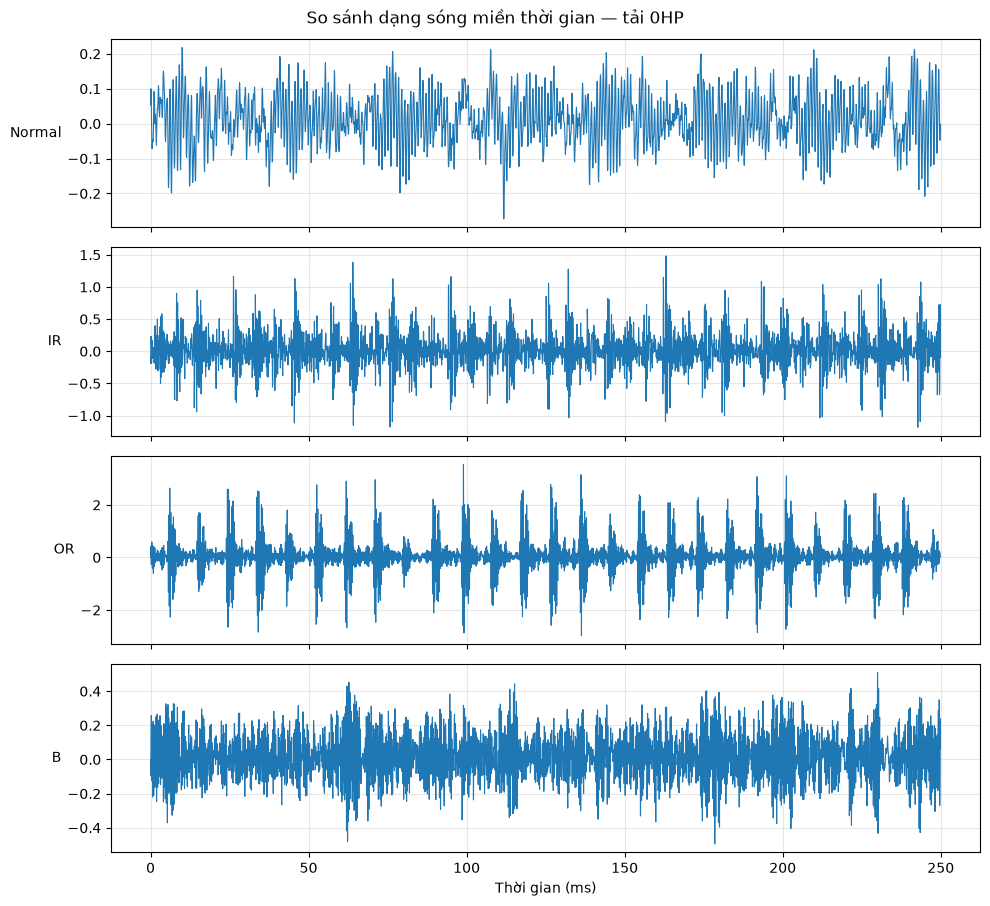

In [6]:
N_SECONDS = 0.25  # chỉ xem 250ms đầu cho dễ quan sát tính xung

fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.3 * len(signals)), sharex=True)
n_samples_plot = int(N_SECONDS * FS)
t_ms = np.arange(n_samples_plot) / FS * 1000

for ax, (label, x) in zip(axes, signals.items()):
    ax.plot(t_ms, x[:n_samples_plot], linewidth=0.8)
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Thời gian (ms)")
fig.suptitle(f"So sánh dạng sóng miền thời gian — tải {LOAD_HP}HP")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_time_domain_comparison.png", dpi=150)
plt.show()

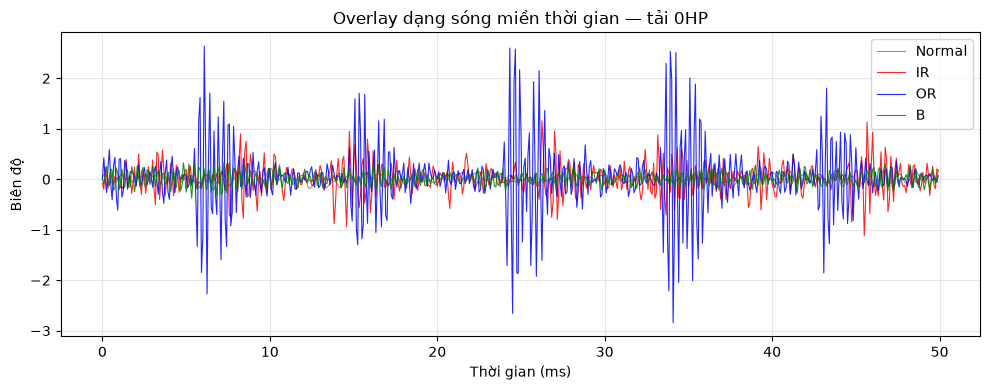

In [7]:
# --- BỔ SUNG A: Overlay 4 nhãn trên CÙNG 1 trục — so sánh trực tiếp biên độ/tính xung ---
N_SECONDS = 0.05
fig, ax = plt.subplots(figsize=(10, 4))
n_samples_plot = int(N_SECONDS * FS)
t_ms = np.arange(n_samples_plot) / FS * 1000

label_colors = {"Normal": "gray", "IR": "red", "OR": "blue", "B": "green"}

for label, x in signals.items():
    ax.plot(t_ms, x[:n_samples_plot], linewidth=0.8, alpha=0.85,
            color=label_colors.get(label, "black"), label=label)

ax.set_xlabel("Thời gian (ms)")
ax.set_ylabel("Biên độ")
ax.set_title(f"Overlay dạng sóng miền thời gian — tải {LOAD_HP}HP")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_time_domain_overlay_single_axis.png", dpi=150)
plt.show()

,rms,kurtosis,skewness,peak,std
label,,,,,
Normal,0.0738,-0.2358,-0.0354,0.3113,0.0727
IR,0.2915,2.3959,0.1640,1.7390,0.2912
OR,0.6695,4.6494,0.0569,3.6304,0.6691
B,0.1392,-0.0153,-0.0089,0.6070,0.1387


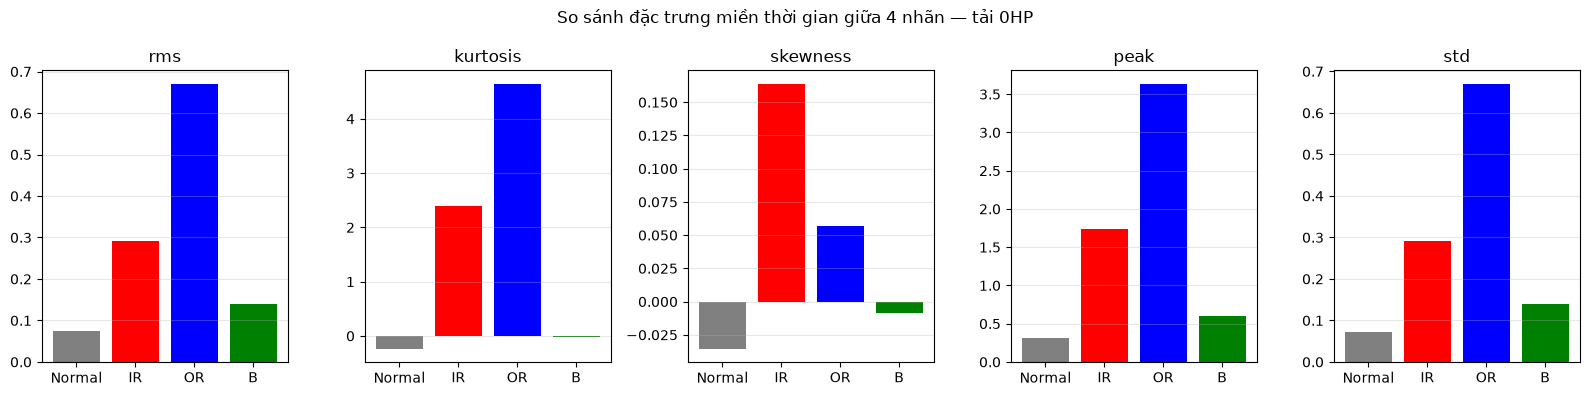

In [ ]:
# --- BỔ SUNG B: Bảng đặc trưng miền thời gian + so sánh giữa 4 nhãn ---
# Dùng features.extract_simple_features()
feature_rows = []
for label, x in signals.items():
    feats = features.extract_simple_features(x)
    feature_rows.append({"label": label, **feats})

time_feature_df = pd.DataFrame(feature_rows).set_index("label")
time_feature_df.to_csv(TABLES_DIR / "02_time_domain_feature_table.csv")
display(time_feature_df.round(4))

feature_names = list(time_feature_df.columns)
fig, axes = plt.subplots(1, len(feature_names), figsize=(3.2 * len(feature_names), 4))
if len(feature_names) == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_names):
    values = time_feature_df[feat]
    bar_colors = [label_colors.get(lbl, "black") for lbl in values.index]
    ax.bar(values.index, values.values, color=bar_colors)
    ax.set_title(feat)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle(f"So sánh đặc trưng miền thời gian giữa 4 nhãn — tải {LOAD_HP}HP")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_time_domain_feature_comparison.png", dpi=150)
plt.show()

## Quan sát

Điền nhận xét thực tế sau khi chạy với dữ liệu CWRU thật:
- Nhãn nào có biên độ đỉnh (peak) lớn nhất?
- Nhãn nào thể hiện rõ tính xung (các đỉnh nhọn lặp lại theo chu kỳ) nhất?
- Normal có đặc điểm gì khác biệt rõ rệt so với 3 nhãn lỗi?

Hình đã lưu tại `outputs/figures/02_time_domain_comparison.png` — dùng
trực tiếp cho phần Cơ sở lý thuyết của báo cáo.